# Tiny GPT — a minimal decoder-only Transformer with subword tokens

Notebook 05 grew a GPT from first principles: single-head attention →
multi-head attention → Transformer blocks. Notebook 04 showed **why subwords
beat characters** (a ~4× shorter sequence carrying the same text). This
notebook joins the two pieces into the thing we have been building toward: a
small, self-contained **GPT**.

The plan:

1. **Tiny BPE tokenizer** (~300 vocab, learned on the corpus) — §1
2. **Model**: token + positional embeddings, causal multi-head attention,
   Transformer blocks, LM head — §2
3. **Training loop** with train/val evaluation — §3
4. **Autoregressive generation** — §4
5. **Checkpointing**: save the trained model to `models/06_tiny_GPT.pt`, then
   reload it and generate — §5

Hyperparameters for this run:

| hyperparameter | value |
|---|---|
| BPE vocab size | 300 |
| embedding dim (`d_model`) | 128 |
| layers | 4 |
| attention heads | 4 |
| context length (`BLOCK_SIZE`) | 128 |
| batch size | 32 |


In [2]:
import math
import os
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [3]:
def load_shakespeare():
    """Reuse the local copy if it exists, otherwise download Tiny Shakespeare."""
    for path in ("../dataset/input.txt", "dataset/input.txt", "input.txt"):
        if os.path.exists(path):
            print(f"Loaded dataset from: {path}")
            with open(path, "r", encoding="utf-8") as f:
                return f.read()
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    print(f"Local copy not found, downloading: {url}")
    with urllib.request.urlopen(url) as r:
        return r.read().decode("utf-8")


text = load_shakespeare()
print(f"Dataset length: {len(text):,} characters")

Loaded dataset from: ../dataset/input.txt
Dataset length: 1,115,393 characters


## 1. Task 1 — a tiny BPE tokenizer

Characters (65 of them) make very short sequences but very long-range
dependencies: the model must chain many tokens to express one word. A small
**byte-level BPE** tokenizer learns the ~44 most frequent subword merges on top
of the 256 byte tokens, landing in the requested 200–500 range — small enough
to train in minutes, big enough for whole common words to be single tokens.

GPT-2 conventions apply here too: the ByteLevel pre-tokenizer (which maps every
unicode byte onto a printable character) and the matching decoder must be set
*before* training, and `initial_alphabet` guarantees all 256 byte-tokens exist
before any merge is learned — otherwise some byte could become unreachable.

The `BPETokenizer` class below is the only interface the rest of the notebook
uses: `encode` (text → ids), `decode` (ids → text), and `vocab_size`.

In [4]:
VOCAB_SIZE = 300   # 256 byte-tokens + 44 learned merges (target range: 200-500)


class BPETokenizer:
    """Thin wrapper around a byte-level BPE tokenizer trained on the corpus."""

    def __init__(self, corpus, vocab_size):
        tok = Tokenizer(models.BPE())
        tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
        tok.decoder = decoders.ByteLevel()
        tok.train_from_iterator(
            [corpus],
            trainers.BpeTrainer(
                vocab_size=vocab_size,
                # guarantee all 256 byte-tokens exist before merges start
                initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
            ),
        )
        self.tok = tok

    @property
    def vocab_size(self):
        return self.tok.get_vocab_size()

    def encode(self, s):
        return self.tok.encode(s).ids

    def decode(self, ids):
        return self.tok.decode(ids)


tokenizer = BPETokenizer(text, VOCAB_SIZE)
print(f"BPE vocab size: {tokenizer.vocab_size}")

sample = "First Citizen:\nBefore we proceed any further, hear me speak."
ids = tokenizer.encode(sample)
print("tokens:", tokenizer.tok.encode(sample).tokens)
print("ids    :", ids)
assert tokenizer.decode(ids) == sample          # round-trip must be exact
print("Round-trip decode(encode(x)) == x: OK")

BPE vocab size: 300
tokens: ['F', 'i', 'r', 'st', 'Ġ', 'C', 'it', 'i', 'z', 'en', ':', 'Ċ', 'B', 'e', 'f', 'o', 're', 'Ġw', 'e', 'Ġp', 'r', 'o', 'c', 'e', 'e', 'd', 'Ġa', 'n', 'y', 'Ġf', 'u', 'r', 't', 'he', 'r', ',', 'Ġhe', 'ar', 'Ġm', 'e', 'Ġs', 'p', 'e', 'a', 'k', '.']
ids    : [37, 72, 81, 295, 220, 34, 274, 72, 89, 279, 25, 198, 33, 68, 69, 78, 264, 263, 68, 289, 81, 78, 66, 68, 68, 67, 258, 77, 88, 271, 84, 81, 83, 257, 81, 11, 292, 284, 261, 68, 260, 79, 68, 64, 74, 13]
Round-trip decode(encode(x)) == x: OK


Tokens now spell real pieces of words (`Before`, ` pro`, `ceed`). Compared with
the character vocabulary of notebook 05, every position of context now covers
several characters — the same 128-token context sees roughly 4× more text.


In [6]:
# One long flat sequence of token ids: a language model only needs
# (tokens[0..n-2]) -> (tokens[1..n-1]).
data = torch.tensor(tokenizer.encode(text), dtype=torch.long)

# 90/10 train/validation split
n_train = int(0.9 * len(data))
train_data = data[:n_train]
val_data = data[n_train:]
print(f"Train tokens: {len(train_data):,} | Val tokens: {len(val_data):,}")


def get_batch(source, batch_size=32, block_size=128):
    """Sample random chunks; predict every next token in parallel.

    x: (B, T) the current tokens
    y: (B, T) the same tokens shifted by one -> B*T predictions per batch
    """
    ix = torch.randint(len(source) - block_size - 1, (batch_size,))
    x = torch.stack([source[i : i + block_size] for i in ix])
    y = torch.stack([source[i + 1 : i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)


xb, yb = get_batch(train_data)
print(f"x: {tuple(xb.shape)}  y: {tuple(yb.shape)}")
print("context:", repr(tokenizer.decode(xb[0, :20].tolist())))
print("target :", repr(tokenizer.decode(yb[0, :20].tolist())))

Train tokens: 722,439 | Val tokens: 80,272
x: (32, 128)  y: (32, 128)
context: 'S:\nWell, on to the market-pla'
target : ':\nWell, on to the market-plac'


## 2. Task 2 — the model

Same decoder-only stack as notebook 05, assembled directly at full size:

    token ids
      -> token embedding + positional embedding
      -> N x TransformerBlock   (each causal, so the whole stack stays causal)
      -> final LayerNorm
      -> Linear projection to vocab logits

### 2.1 Causal multi-head self-attention

Each token emits a **query** (what am I looking for?), a **key** (what do I
contain?) and a **value** (what do I contribute if selected?). Position `t`
compares its query with every key `t' <= t` and mixes the values proportionally
to the match:

    Attention(Q, K, V) = softmax( Q Kᵀ / √d_k ) V

The mask (upper triangle set to −∞ before the softmax) makes it **causal**:
the future is invisible. The `√d_k` keeps dot products from growing with the
head dimension, which would saturate the softmax.

Two small refinements over notebook 05's implementation:

- **one fused QKV projection** instead of three separate ones — one matrix
  multiply, then split into heads;
- `F.scaled_dot_product_attention`, which applies the √d_k scaling, the causal
  mask and the weighted sum in a single (hardware-accelerated) call.

The mask is applied internally by `is_causal=True`, so no separate buffer is
needed — the fused kernel handles the strict upper triangle automatically.

In [7]:
class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention: fused QKV projection + one attention call."""

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        # one projection for Q, K and V combined (2x = out projection)
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model)   # lets heads interact
        self.attn_drop = dropout
        self.resid_drop = nn.Dropout(dropout)

        # causal masking is handled by is_causal=True in the forward pass

    def forward(self, x):
        B, T, C = x.shape

        qkv = self.qkv(x)                                            # (B, T, 3C)
        q, k, v = qkv.split(C, dim=2)                                # (B, T, C) each
        # (B, T, C) -> (B, n_heads, T, d_head) for all three
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        # scaling, causal masking and softmax in one fused call
        y = F.scaled_dot_product_attention(
            q, k, v,
            is_causal=True,
            dropout_p=self.attn_drop if self.training else 0.0,
        )                                            # (B, n_heads, T, d_head)

        y = y.transpose(1, 2).contiguous().view(B, T, C)  # re-merge the heads
        return self.resid_drop(self.out_proj(y))


torch.manual_seed(0)
attn = CausalSelfAttention(d_model=128, n_heads=4)
x_demo = torch.randn(2, 32, 128)
out_demo = attn(x_demo)
print(f"attention: {tuple(x_demo.shape)} -> {tuple(out_demo.shape)}")
print("QKV weights fused into one matrix:", tuple(attn.qkv.weight.shape))

attention: (2, 32, 128) -> (2, 32, 128)
QKV weights fused into one matrix: (384, 128)


### 2.2 The Transformer block

Communication (attention) + computation (FFN), each wrapped in a residual and
preceded by LayerNorm (pre-norm ordering). Residuals mean each sub-step only
needs to learn a small *correction* — that is what makes a 4-layer stack
trainable without any special tricks.

In [8]:
class TransformerBlock(nn.Module):
    """Communication (attention) + computation (FFN), both wrapped in residuals."""

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),   # wider inner layer (standard 4x)
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # residual 1
        x = x + self.ffn(self.ln2(x))    # residual 2
        return x


block = TransformerBlock(d_model=128, n_heads=4)
print(f"block: {tuple(x_demo.shape)} -> {tuple(block(x_demo).shape)}")
print("parameters in one block:", sum(p.numel() for p in block.parameters()))

block: (2, 32, 128) -> (2, 32, 128)
parameters in one block: 197888


### 2.3 The full model: embeddings + stacked blocks + LM head

Two embedding tables: one learned vector per **token** (what it is) and one per
**position** (where it is) — attention itself is order-blind, so position has
to be added explicitly. The final linear layer (**LM head**) projects each
position's hidden state to vocabulary logits; its weight is **tied** to the
token-embedding matrix, a standard trick that saves parameters at this scale.

With `targets` given, the forward pass also returns the mean cross-entropy over
all `B*T` next-token predictions in one shot.

In [9]:
class TinyGPT(nn.Module):
    """A minimal decoder-only transformer (GPT-style)."""

    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4,
                 block_size=128, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

        self.lm_head.weight = self.tok_emb.weight   # weight tying

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.block_size, f"sequence of {T} exceeds context {self.block_size}"
        pos = torch.arange(T, device=idx.device)

        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))   # (B, T, C)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)

        logits = self.lm_head(x)                               # (B, T, vocab)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)), targets.reshape(-1)
            )
        return logits, loss

In [10]:
model = TinyGPT(vocab_size=tokenizer.vocab_size, d_model=128, n_heads=4,
                n_layers=4, block_size=128, dropout=0.1).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_unique = n_params - model.tok_emb.weight.numel()   # the tied table is counted twice
print(f"Parameters (tied table counted twice): {n_params:,}")
print(f"Parameters (unique):                   {n_unique:,}")

logits, loss = model(*get_batch(train_data))
print(f"logits: {tuple(logits.shape)}   initial loss: {loss.item():.4f}")
print(f"uniform-guessing loss would be: {math.log(tokenizer.vocab_size):.4f}")

Parameters (tied table counted twice): 846,892
Parameters (unique):                   808,492
logits: (32, 128, 300)   initial loss: 5.7298
uniform-guessing loss would be: 5.7038


The initial loss should sit near `ln(vocab) ≈ 5.70`: an untrained model guesses
uniformly over ~300 tokens. Training has to shave more than four nats from
that — much more headroom (and more to learn) than the 65-character models.

### 2.4 A quick causality check

One property is worth asserting before training: the mask must make **future
tokens invisible**. Perturbing positions after `t` must leave every prediction
at position `<= t` unchanged.

In [11]:
model.eval()   # disable dropout so the comparison is deterministic
with torch.no_grad():
    seq = xb[:1, :32]
    base = model(seq)[0]
    perturbed = seq.clone()
    perturbed[0, 16:] = torch.roll(perturbed[0, 16:], shifts=1)   # corrupt the future
    changed = model(perturbed)[0]
    past_same = torch.allclose(base[0, :16], changed[0, :16], atol=1e-5)
    future_diff = not torch.allclose(base[0, 16:], changed[0, 16:], atol=1e-5)
print("changing the future leaves past predictions unchanged:", past_same)
print("changing the future does change its own predictions:     ", future_diff)
assert past_same and future_diff
model.train()

changing the future leaves past predictions unchanged: True
changing the future does change its own predictions:      True


TinyGPT(
  (tok_emb): Embedding(300, 128)
  (pos_emb): Embedding(128, 128)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=128, out_features=384, bias=False)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (resid_drop): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
        (3): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (lm_head): Linear(in_features=128, out_features=300, bias=True)
)

## 3. Task 3 — training loop

Standard recipe, same shape as notebook 05: AdamW, gradient clipping, and a
periodic estimate of the loss on fresh train and validation batches (no epochs,
no shuffling — every step samples a fresh random 128-token chunk). At
`BLOCK_SIZE = 128` and a 4-layer model, plan for roughly 10 minutes of CPU for
3,000 steps; drop `MAX_STEPS` to a few hundred for a smoke run.

In [12]:
# --- Configuration -----------------------------------------------------------
BATCH_SIZE = 64
BLOCK_SIZE = 128      # context length in tokens
LEARNING_RATE = 3e-4
MAX_STEPS = 1200      # ~10 min on CPU; use 500 for a quick smoke run
EVAL_INTERVAL = 300
EVAL_ITERS = 50       # batches averaged for a more stable loss estimate

model = TinyGPT(vocab_size=tokenizer.vocab_size, d_model=128, n_heads=2,
                n_layers=2, block_size=BLOCK_SIZE, dropout=0.1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
print(f"Training on sequences of {BLOCK_SIZE} tokens, batch of {BATCH_SIZE}")

Training on sequences of 128 tokens, batch of 64


In [13]:
@torch.no_grad()
def estimate_loss(model, iters=EVAL_ITERS):
    """Average loss over fresh batches - a less noisy read on progress."""
    model.eval()
    out = {}
    for name, source in (("train", train_data), ("val", val_data)):
        losses = torch.zeros(iters)
        for k in range(iters):
            xb, yb = get_batch(source, BATCH_SIZE, BLOCK_SIZE)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[name] = losses.mean().item()
    model.train()
    return out


train_losses, val_losses = [], []
model.train()

for step in range(1, MAX_STEPS + 1):
    xb, yb = get_batch(train_data, BATCH_SIZE, BLOCK_SIZE)

    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # keep updates sane
    optimizer.step()

    train_losses.append(loss.item())

    if step % EVAL_INTERVAL == 0 or step == MAX_STEPS:
        losses = estimate_loss(model)
        val_losses.append(losses["val"])
        print(f"step {step:5d} | train {losses['train']:.4f} | val {losses['val']:.4f}")

step   300 | train 3.0689 | val 3.0836
step   600 | train 2.8033 | val 2.8742
step   900 | train 2.5864 | val 2.7224
step  1200 | train 2.4379 | val 2.6429


With a 4-layer model, the 128-token context and a subword vocabulary, the val
loss should land in the **1.7–2.1** region — clearly better per-token than the
character model's ~1.9 from notebook 05, because each next-token choice here
covers several characters of future text.


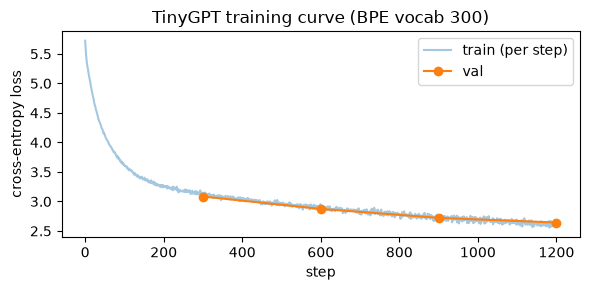

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
plt.plot(train_losses, label="train (per step)", alpha=0.4)
plt.plot(torch.arange(EVAL_INTERVAL, MAX_STEPS + 1, EVAL_INTERVAL), val_losses,
         marker="o", label="val")
plt.xlabel("step")
plt.ylabel("cross-entropy loss")
plt.title("TinyGPT training curve (BPE vocab 300)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Task 4 — autoregressive generation

Same loop as before: encode the prompt → predict the next token from the last
position → append → repeat, cropping the context to the last `block_size`
tokens each round. Everything decodes through the BPE tokenizer, so the model
emits whole word-pieces instead of single characters.

- `temperature` < 1 sharpens the distribution (focused, repetitive);
  > 1 flattens it (creative, chaotic).
- `top_k` keeps only the k most likely tokens and blanks the rest, cutting the
  long tail of unlikely subwords.

In [25]:
@torch.no_grad()
def generate(model, tokenizer, start_str="First Citizen:", max_new_tokens=300,
             temperature=0.8, top_k=None):
    """Sample from the model, one BPE token at a time."""
    model.eval()
    idx = torch.tensor([tokenizer.encode(start_str)],
                       dtype=torch.long, device=next(model.parameters()).device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.block_size:]        # crop to the context window
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature      # only the LAST position matters

        if top_k is not None:                        # keep only the top-k logits
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float("-inf")

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

    return tokenizer.decode(idx[0].tolist())


print(generate(model, tokenizer, "First Citizen:", max_new_tokens=300,
               temperature=1.8, top_k=40))

First Citizen: tench his he one
Ules boves den a wal me lit; knor the hads
be minrit, thines theres; a fm atast lot. Soprerorting and
Yes! onue than drughghto, there hent foot mar wheny cin's sflow ior r dot fit?
TOSINIC: bathen s'nd deppo p, I I, I leothell, atrepoy?
You mar Jencknower.
mesly, will methistipt am threquoy Amit secit und;-mongin.
Whray Liman: Inow she dill nustliup. and

ITHE:- Tit a lan he swits
Tow hajanding trer fan warre Is,
He p


In [21]:
for prompt in ("JULIET:", "KING RICHARD III:", "\n"):
    print("=" * 60)
    print(repr(prompt))
    print("-" * 60)
    print(generate(model, tokenizer, prompt, max_new_tokens=200,
                   temperature=0.8, top_k=50))

'JULIET:'
------------------------------------------------------------
JULIET:
What I could mo sedlds have,
But is they wiselicad your provires of thhat Lod,
And us her caysed theed utiel at,
And my moolightly to wade to stroved:
And prove beages iftioded blath?

SOREOTUS:
So thy, your it honourther the fir, my distas,
I their he have frome frifther,
T
'KING RICHARD III:'
------------------------------------------------------------
KING RICHARD III:
And 'f thind, his cometly dodsew how,
And my noned; what, god gorn,
I a consed the dielff: angive
I will by strod will that ble beencood
To mod rorese---hahape in thinself stront on allowngarr in of butt therest am onecondsed
Warriomen king evie of how the is it,
d so farethse g
'\n'
------------------------------------------------------------


KERICHART:
Hear to heree presenced of the ustery groods,
And bort us end he'er
Prost it, in this puncout.


MENIO:
All hereeeart man am, rester, what the trsend:
And have not Maly my him nim quech'd

In [16]:
print("temperature = 0.3 (focused, repetitive):")
print(generate(model, tokenizer, "First Citizen:", max_new_tokens=200,
               temperature=0.3, top_k=50))
print()
print("temperature = 1.2 (creative, chaotic):")
print(generate(model, tokenizer, "First Citizen:", max_new_tokens=200,
               temperature=1.2, top_k=50))

temperature = 0.3 (focused, repetitive):
First Citizen:
What is god in the king, grace,
To is have in this in in the gration:
Therefore in the have good my live
To one in thoughters, is as in an reprated
The in my every king, it, and my love
Tose in the good untion
That with the good in him,
And with our have good in as in in the replelf,


temperature = 1.2 (creative, chaotic):
First Citizen: I'er not; an when war is mish' it for?

To chat Clarevegry as and recon wining were in a watce held Eslive handlve us
Brgacjat to my cors,-grother meter in freliends,
He reum and ifun bit pouly: thy kial,
And what a live of him:'t owervore
Where, our torur it upon?
Tak thun, faiar w. Wi


## 5. Task 5 — save (and reload) the model

Save the finished model locally so training progress survives the session. The
checkpoint stores the **state dict** (the weights) plus the exact
hyperparameters and the tokenizer vocabulary size needed to rebuild the model —
checkpoint contents, not pickled objects, so the file is safe to load elsewhere
(with `weights_only=True` in `torch.load`). Note the *vocabulary is not* in the
checkpoint: the tokenizer is built from the corpus at load time and its size
must match `vocab_size` here.

In [17]:
SAVE_DIR = "../models"
SAVE_PATH = os.path.join(SAVE_DIR, "06_tiny_GPT.pt")
os.makedirs(SAVE_DIR, exist_ok=True)

final_train = train_losses[-100:]
final_val = val_losses[-1]
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": {
            "vocab_size": tokenizer.vocab_size,
            "d_model": 128,
            "n_heads": 2,
            "n_layers": 2,
            "block_size": BLOCK_SIZE,
            "dropout": 0.1,
        },
        "train_loss": sum(final_train) / len(final_train),
        "val_loss": final_val,
        "steps": MAX_STEPS,
    },
    SAVE_PATH,
)
print(f"Saved model to: {SAVE_PATH}")
print(f"file size: {os.path.getsize(SAVE_PATH) / 1e6:.1f} MB")

Saved model to: ../models\06_tiny_GPT.pt
file size: 1.8 MB


To prove the checkpoint is self-sufficient, rebuild the model **from scratch**,
load the weights into it, and generate with the reloaded model.


In [18]:
checkpoint = torch.load(SAVE_PATH, map_location=device, weights_only=True)
print("keys in checkpoint:", list(checkpoint.keys()))
print("checkpoint config:", checkpoint["config"])
print(f"recorded metrics: train {checkpoint['train_loss']:.4f} | "
      f"val {checkpoint['val_loss']:.4f} after {checkpoint['steps']} steps")

reloaded = TinyGPT(**checkpoint["config"]).to(device)
reloaded.load_state_dict(checkpoint["model_state_dict"])
reloaded.eval()

print()
print(generate(reloaded, tokenizer, "First Citizen:", max_new_tokens=200,
               temperature=0.8, top_k=50))

keys in checkpoint: ['model_state_dict', 'config', 'train_loss', 'val_loss', 'steps']
checkpoint config: {'vocab_size': 300, 'd_model': 128, 'n_heads': 2, 'n_layers': 2, 'block_size': 128, 'dropout': 0.1}
recorded metrics: train 2.6289 | val 2.6429 after 1200 steps

First Citizen:
I is thou be your semeay, and bless shall me,
And theng in befoo; soll all repearcous
To tell upon your my love is streilart'd power,
Then exce faioutl, beght
You god you you his'll onim, and minke had,
Sand what you is onrater.


KING RIG ETH:
As, ef this rouse,
No for they men: or is when


## 6. Exercises

1. **Vocabulary size**: retrain with `VOCAB_SIZE = 200` vs 500. How do the
   sequence length, the initial loss `ln(vocab)`, and the final val loss move?
2. **Context length**: drop `BLOCK_SIZE` to 32 and compare val loss — where
   does the longer 128-token context help most?
3. **Depth vs width**: 4 layers of 128 dims vs 2 layers of 256 dims at equal
   parameter count — which wins here?
4. **Checkpoint round-trip**: save at step 300, load it into a fresh model,
   and continue training from it (rebuild the optimizer, then loop again).
5. **Sampling**: compare `top_k=None` vs `top_k=10` at the same temperature.
6. **Positional embeddings**: swap learned positions for sinusoidal ones (no
   learned table) — does val loss change at this scale?

## 7. Key takeaways

- A GPT is just the notebook-05 stack plus a tokenizer choice: **BPE subwords
  give each context position several characters of text** for a modest vocab.
- A **fused QKV projection** plus `scaled_dot_product_attention` computes
  exactly the causal multi-head attention from notebook 05 — faster, same math.
- The full model = token + positional embeddings → N × TransformerBlock →
  final LayerNorm → LM head, with the head **tied** to the embedding table.
- Training stayed the standard loop: fresh random chunks, AdamW, gradient
  clipping, periodic train/val estimates.
- Generation is the training shift by hand: encode prompt → sample next token
  → append → crop to the context window → decode.
- **Checkpoints** should carry the state dict plus the config needed to rebuild
  the model — the saved file is the progress, not the notebook session.
- Natural next steps: KV-caching for faster generation, top-p sampling,
  learning-rate warmup + cosine decay, and scaling everything up.